# 04 · Error Analysis

Where does the model fail, and why?

**What this notebook shows:**
- Confusion matrix (which classes are confused with which)
- Worst-performing classes by per-class accuracy
- Most confused disease pairs (challenging look-alikes)
- Highest-confidence wrong predictions (likely dataset issues or genuinely hard cases)

## Setup

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np, matplotlib.pyplot as plt, pandas as pd, seaborn as sns
from src.evaluate import compute_metrics
from src.error_analysis import top_confused_pairs, worst_classes_by_accuracy, hardest_examples

In [2]:
# Load predictions saved from 02_training.ipynb
data = np.load('../models/test_predictions.npz', allow_pickle=True)
y_true, y_pred, probs = data['y_true'], data['y_pred'], data['probs']
class_names = list(data['class_names'])
print(f'Test set size: {len(y_true)}')

Test set size: 8147


## Overall metrics

In [3]:
metrics = compute_metrics(y_true, y_pred, class_names)
print(f'Overall accuracy: {metrics["overall_accuracy"]*100:.2f}%')
pd.DataFrame(metrics['classification_report']).T.head(10)

Overall accuracy: 98.06%


,precision,recall,f1-score,support
Apple___Apple_scab,1.000000,0.835165,0.910180,91.0
Apple___Black_rot,0.977528,1.000000,0.988636,87.0
Apple___Cedar_apple_rust,1.000000,0.918919,0.957746,37.0
Apple___healthy,0.988971,0.996296,0.992620,270.0
Blueberry___healthy,0.994975,1.000000,0.997481,198.0
Cherry_(including_sour)___Powdery_mildew,1.000000,0.960227,0.979710,176.0
Cherry_(including_sour)___healthy,1.000000,0.992000,0.995984,125.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.810127,0.901408,0.853333,71.0
Corn_(maize)___Common_rust_,1.000000,1.000000,1.000000,168.0
Corn_(maize)___Northern_Leaf_Blight,0.942857,0.897959,0.919861,147.0


## Confusion matrix

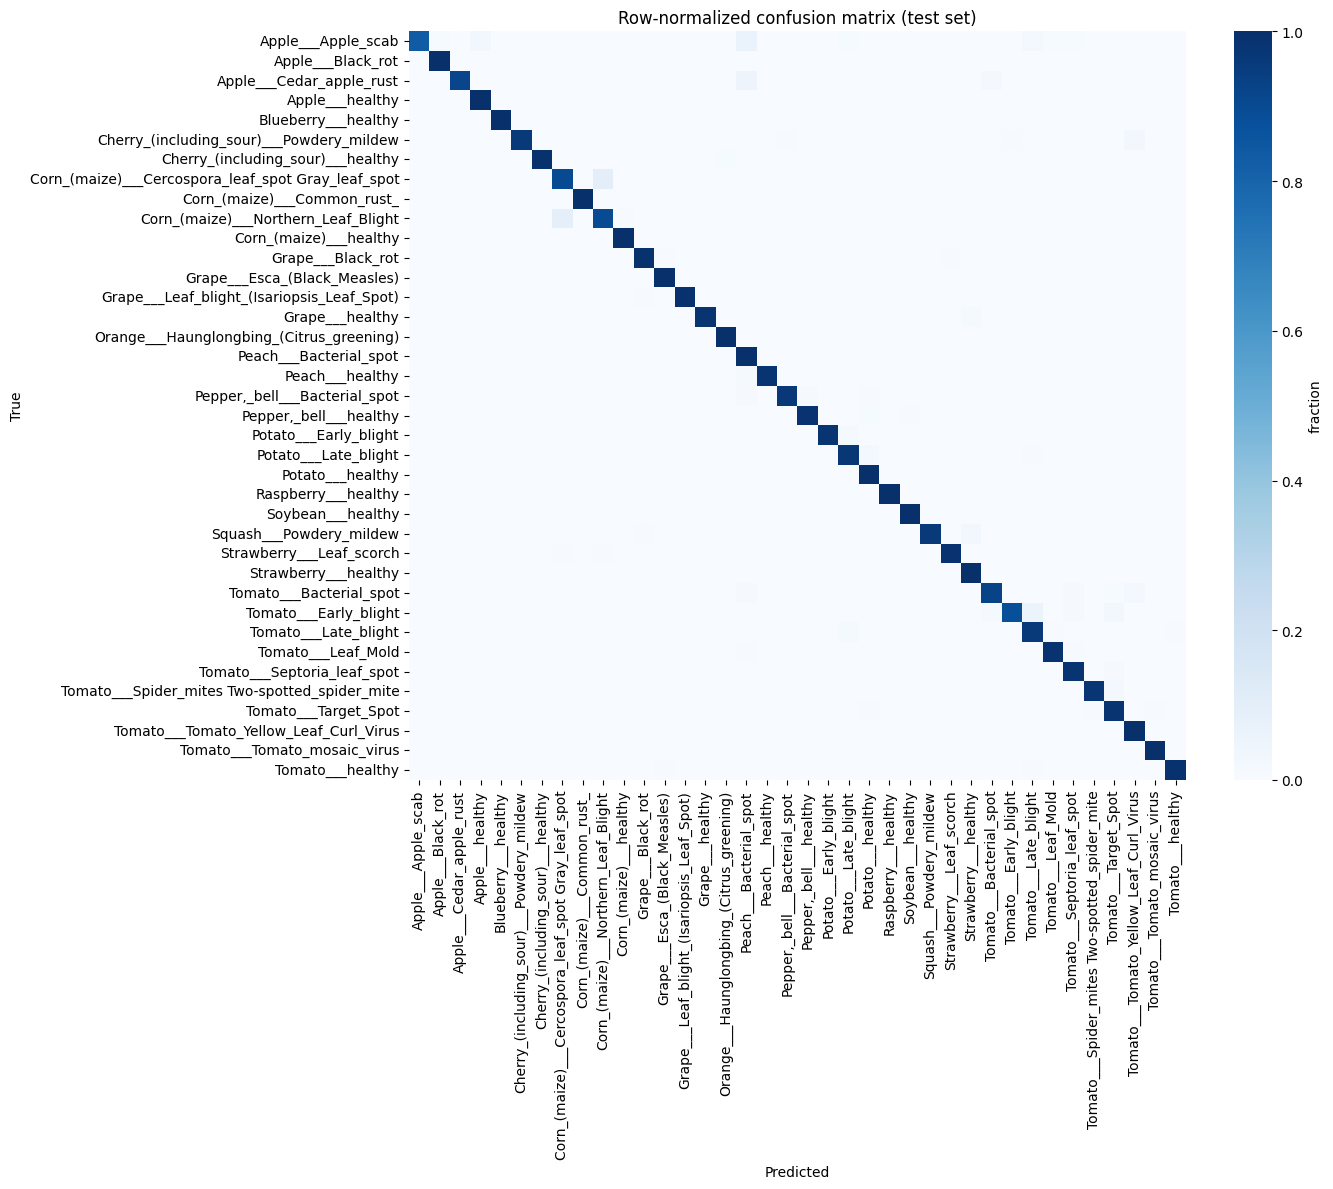

In [4]:
cm = metrics['confusion_matrix']
fig, ax = plt.subplots(figsize=(14, 12))
# Normalize rows so each row sums to 1 - shows recall per class
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(cm_norm, xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=ax, cbar_kws={'label': 'fraction'})
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Row-normalized confusion matrix (test set)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig('../docs/confusion_matrix.png', dpi=150); plt.show()

## Worst 10 classes by per-class accuracy

In [5]:
worst = worst_classes_by_accuracy(metrics['per_class_accuracy'], top_n=10)
pd.DataFrame(worst, columns=['class', 'accuracy'])

,class,accuracy
0,Apple___Apple_scab,0.835165
1,Tomato___Early_blight,0.882353
2,Corn_(maize)___Northern_Leaf_Blight,0.897959
3,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.901408
4,Apple___Cedar_apple_rust,0.918919
5,Tomato___Bacterial_spot,0.927445
6,Tomato___Late_blight,0.958333
7,Squash___Powdery_mildew,0.958801
8,Cherry_(including_sour)___Powdery_mildew,0.960227
9,"Pepper,_bell___Bacterial_spot",0.968153


## Most confused class pairs

Which (true, predicted) pairs account for the most mistakes? Often these are biologically plausible look-alikes. For example, Early Blight vs. Target Spot both show concentric ring lesions.

In [6]:
pairs = top_confused_pairs(metrics['confusion_matrix'], class_names, top_n=15)
pd.DataFrame(pairs, columns=['true', 'predicted', 'count'])

,true,predicted,count
0,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,14
1,Tomato___Early_blight,Tomato___Late_blight,10
2,Squash___Powdery_mildew,Strawberry___healthy,8
3,Tomato___Bacterial_spot,Tomato___Tomato_Yellow_Leaf_Curl_Virus,8
4,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,7
5,Apple___Apple_scab,Peach___Bacterial_spot,6
6,Tomato___Bacterial_spot,Tomato___Septoria_leaf_spot,6
7,Cherry_(including_sour)___Powdery_mildew,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5
8,Tomato___Early_blight,Tomato___Target_Spot,5
9,Tomato___Late_blight,Potato___Late_blight,5


## Most confident wrong predictions

These are the scariest errors, because the model got it wrong AND was very confident. Some will turn out to be mislabeled images in the dataset; others are genuinely deceiving examples.

In [7]:
hard = hardest_examples(y_true, y_pred, probs, top_n=15)
df_hard = pd.DataFrame(hard)
df_hard['true_name'] = df_hard['true_class'].apply(lambda i: class_names[i])
df_hard['pred_name'] = df_hard['predicted_class'].apply(lambda i: class_names[i])
df_hard[['true_name', 'pred_name', 'confidence']]

,true_name,pred_name,confidence
0,Tomato___healthy,Grape___Esca_(Black_Measles),1.000000
1,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___healthy,0.999995
2,Tomato___Late_blight,Tomato___Leaf_Mold,0.999695
3,Tomato___Early_blight,Tomato___Late_blight,0.999332
4,Squash___Powdery_mildew,Strawberry___healthy,0.998822
5,Apple___Cedar_apple_rust,Peach___Bacterial_spot,0.998639
6,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.997878
7,"Pepper,_bell___healthy",Potato___healthy,0.997599
8,Cherry_(including_sour)___healthy,Orange___Haunglongbing_(Citrus_greening),0.997221
9,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,0.991141


## Takeaways

Fill in after running:
- Biggest confusion clusters (e.g., tomato-tomato disease confusion makes sense — same plant, similar leaf morphology)
- Whether healthy/diseased boundaries are clean
- Whether any hard examples look mislabeled